## LOADING THE DATASET

In [2]:
from pyspark.sql import SparkSession

# Initialize the Spark Session
spark = SparkSession.builder \
    .appName("LoadPhishingData") \
    .getOrCreate()

# Define the container path where your file is mounted
file_path = "/home/jovyan/work/email_security_data.csv"

# Load the dataset into a DataFrame
df1 = spark.read.csv(file_path, header=True, inferSchema=True)

# Verify it loaded correctly by showing the first 5 rows
df1.show(5)

+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|EmailAttachments|URLCount|SenderReputation|SuspiciousKeywords|EmailSize|LinkEntropy|DomainRiskScore|AccountAge|PhishingLabel|
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|               3|       7|             169|                 1|   259.69|      3.046|          0.239|        78|            1|
|               0|       4|              87|                 7|   322.43|      2.347|          0.494|        24|            0|
|               0|       4|             195|                 1|    92.37|      3.795|          0.583|        11|            0|
|               0|       2|              85|                 0|   447.77|      2.667|          0.123|        72|            0|
|               3|       4|             163|                 4|    294.7|        0.0|          0.889|        44

## Structure of the DataFrame

In [3]:
# Display the column names and data types in a tree format
print("1. DataFrame Structure & Data Types:")
df1.printSchema()

# Display the exact column names as a list
print("2. Column Names:")
print(df1.columns)

# Calculate and display the total number of rows and columns
total_rows = df1.count()
total_columns = len(df1.columns)

print("\n3. DataFrame Dimensions:")
print(f"Total Number of Rows: {total_rows}")
print(f"Total Number of Columns: {total_columns}")

1. DataFrame Structure & Data Types:
root
 |-- EmailAttachments: integer (nullable = true)
 |-- URLCount: integer (nullable = true)
 |-- SenderReputation: integer (nullable = true)
 |-- SuspiciousKeywords: integer (nullable = true)
 |-- EmailSize: double (nullable = true)
 |-- LinkEntropy: double (nullable = true)
 |-- DomainRiskScore: double (nullable = true)
 |-- AccountAge: integer (nullable = true)
 |-- PhishingLabel: integer (nullable = true)

2. Column Names:
['EmailAttachments', 'URLCount', 'SenderReputation', 'SuspiciousKeywords', 'EmailSize', 'LinkEntropy', 'DomainRiskScore', 'AccountAge', 'PhishingLabel']

3. DataFrame Dimensions:
Total Number of Rows: 5000
Total Number of Columns: 9


## Number of rows with missing values in "SuspiciousKeywords" and "EmailSize"

In [4]:
from pyspark.sql import functions as F

zero_count = df1.filter(F.col("SuspiciousKeywords") == 0).count()

print(f"Number of rows with 0's in SuspiciousKeywords column: {zero_count}")

zero_count1 = df1.filter(F.col("EmailSize") == 0).count()

print(f"Number of rows with 0's in EmailSize column: {zero_count1}")

Number of rows with 0's in SuspiciousKeywords column: 861
Number of rows with 0's in EmailSize column: 250


## Replace missing values with Median for "SuspiciousKeywords" and "EmailSize" features

In [5]:
from pyspark.sql import functions as F

# 1. Compute the true median for SuspiciousKeywords (filtering out 0 values)
filtered_keywords = df1.filter(F.col("SuspiciousKeywords") != 0)
median_keywords = filtered_keywords.approxQuantile("SuspiciousKeywords", [0.5], 0.001)[0]

# 2. Compute the true median for EmailSize (filtering out 0 values)
filtered_size = df1.filter(F.col("EmailSize") != 0)
median_size = filtered_size.approxQuantile("EmailSize", [0.5], 0.001)[0]

# Print the calculated medians to verify
print("========================================")
print("Calculated Median Values for Imputation")
print("========================================")
print(f"Median SuspiciousKeywords: {median_keywords}")
print(f"Median EmailSize: {median_size}\n")

# 3. Create the second DataFrame (df2) by replacing 0s with the respective medians
df2 = df1.withColumn(
    "SuspiciousKeywords", 
    F.when(F.col("SuspiciousKeywords") == 0, median_keywords).otherwise(F.col("SuspiciousKeywords"))
).withColumn(
    "EmailSize", 
    F.when(F.col("EmailSize") == 0, median_size).otherwise(F.col("EmailSize"))
)

# 4. Verify the results by showing that no 0 values remain in those columns
print("========================================")
print("Verification: Remaining '0' counts in df2")
print("========================================")
zero_keywords = df2.filter(F.col("SuspiciousKeywords") == 0).count()
zero_size = df2.filter(F.col("EmailSize") == 0).count()

print(f"Remaining '0' rows in SuspiciousKeywords: {zero_keywords}")
print(f"Remaining '0' rows in EmailSize: {zero_size}")

Calculated Median Values for Imputation
Median SuspiciousKeywords: 4.0
Median EmailSize: 276.08

Verification: Remaining '0' counts in df2
Remaining '0' rows in SuspiciousKeywords: 0
Remaining '0' rows in EmailSize: 0


## Remove rows where URLCount, SenderReputation, or LinkEntropy has missing values 0

In [6]:
from pyspark.sql import functions as F

# 1. Count rows before removal for documentation
rows_before = df2.count()
a=df2.filter((F.col("URLCount") == 0)).count()
b=df2.filter((F.col("SenderReputation") == 0)).count()
c=df2.filter((F.col("LinkEntropy") == 0)).count()
print("Number of rows with 0 in URLCount is",a)
print("Number of rows with 0 in SenderReputation is",b)
print("Number of rows with 0 in LinkEntropy is",c)
# 2. Create the third DataFrame (df3) by dropping rows where specified columns contain 0
df3 = df2.filter(
    (F.col("URLCount") != 0) & 
    (F.col("SenderReputation") != 0) & 
    (F.col("LinkEntropy") != 0)
)

# 3. Count rows after removal
rows_after = df3.count()
removed_rows = rows_before - rows_after

# 4. Display the results
print("========================================")
print("Data Row Filtering Summary")
print("========================================")
print(f"Total rows in second DataFrame (df2): {rows_before}")
print(f"Total rows in third DataFrame (df3) : {rows_after}")
print(f"Total missing value rows removed    : {removed_rows}\n")

# 5. Quick Verification: Ensure no 0 values remain in the targeted columns
print("========================================")
print("Verification: Remaining '0' counts in df3")
print("========================================")
# Fixed Code (using single quotes inside the F.col function)
print(f"Remaining 0s in URLCount         : {df3.filter(F.col('URLCount') == 0).count()}")
print(f"Remaining 0s in SenderReputation : {df3.filter(F.col('SenderReputation') == 0).count()}")
print(f"Remaining 0s in LinkEntropy      : {df3.filter(F.col('LinkEntropy') == 0).count()}")

Number of rows with 0 in URLCount is 740
Number of rows with 0 in SenderReputation is 250
Number of rows with 0 in LinkEntropy is 250
Data Row Filtering Summary
Total rows in second DataFrame (df2): 5000
Total rows in third DataFrame (df3) : 3847
Total missing value rows removed    : 1153

Verification: Remaining '0' counts in df3
Remaining 0s in URLCount         : 0
Remaining 0s in SenderReputation : 0
Remaining 0s in LinkEntropy      : 0


## Summary Statistics for the SenderReputation feature

 Summary Statistics: SenderReputation   
Minimum Value      : 20.00
Maximum Value      : 199.00
Mean (Average)     : 109.59
Median (50th %ile) : 110.00
Variance           : 2683.75
Standard Deviation : 51.80

Generating distribution histogram...


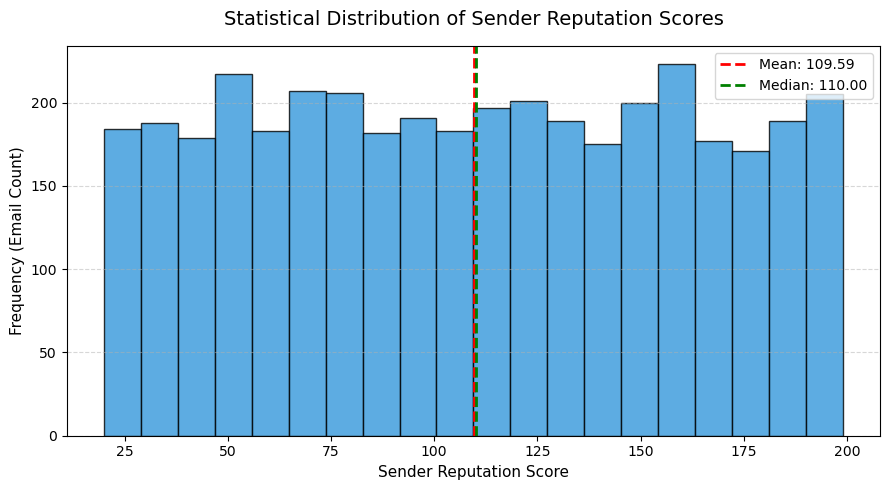

In [7]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# 1. Calculate the foundational summary statistics using PySpark functions
stats = df3.select(
    F.min("SenderReputation").alias("Min"),
    F.max("SenderReputation").alias("Max"),
    F.mean("SenderReputation").alias("Mean"),
    F.variance("SenderReputation").alias("Variance"),
    F.stddev("SenderReputation").alias("StdDev")
).collect()[0]

# 2. Calculate the Median (50th percentile)
median_rep = df3.approxQuantile("SenderReputation", [0.5], 0.001)[0]

# 3. Print out the structured summary report
print("========================================")
print(" Summary Statistics: SenderReputation   ")
print("========================================")
print(f"Minimum Value      : {stats['Min']:.2f}")
print(f"Maximum Value      : {stats['Max']:.2f}")
print(f"Mean (Average)     : {stats['Mean']:.2f}")
print(f"Median (50th %ile) : {median_rep:.2f}")
print(f"Variance           : {stats['Variance']:.2f}")
print(f"Standard Deviation : {stats['StdDev']:.2f}\n")

# 4. Extract data locally to plot the Histogram
print("Generating distribution histogram...")
pdf_rep = df3.select("SenderReputation").toPandas()

plt.figure(figsize=(9, 5))
plt.hist(pdf_rep["SenderReputation"], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
plt.axvline(stats['Mean'], color='red', linestyle='dashed', linewidth=2, label=f"Mean: {stats['Mean']:.2f}")
plt.axvline(median_rep, color='green', linestyle='dashed', linewidth=2, label=f"Median: {median_rep:.2f}")

plt.title("Statistical Distribution of Sender Reputation Scores", fontsize=14, pad=15)
plt.xlabel("Sender Reputation Score", fontsize=11)
plt.ylabel("Frequency (Email Count)", fontsize=11)
plt.legend(loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Quartile information of LinkEntropy feature

 Quartile Information: LinkEntropy     
First Quartile (Q1 - 25th percentile) : 1.3430
Second Quartile (Q2 - Median)         : 2.2200
Third Quartile (Q3 - 75th percentile)  : 3.0740
Interquartile Range (IQR)             : 1.7310
Mathematical Lower Outlier Boundary  : -1.2535
Mathematical Upper Outlier Boundary  : 5.6705

Generating boxplot graph...


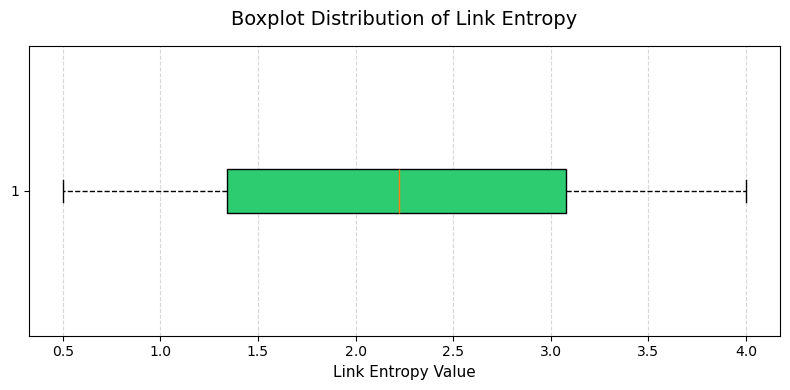

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Compute Quartiles (25th, 50th, and 75th percentiles) using Spark
quartiles = df3.approxQuantile("LinkEntropy", [0.25, 0.5, 0.75], 0.001)
q1 = quartiles[0]
median = quartiles[1]
q3 = quartiles[2]

# 2. Calculate Interquartile Range (IQR) and Outlier Thresholds
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# 3. Print the structured Quartile Report
print("========================================")
print(" Quartile Information: LinkEntropy     ")
print("========================================")
print(f"First Quartile (Q1 - 25th percentile) : {q1:.4f}")
print(f"Second Quartile (Q2 - Median)         : {median:.4f}")
print(f"Third Quartile (Q3 - 75th percentile)  : {q3:.4f}")
print(f"Interquartile Range (IQR)             : {iqr:.4f}")
print(f"Mathematical Lower Outlier Boundary  : {lower_bound:.4f}")
print(f"Mathematical Upper Outlier Boundary  : {upper_bound:.4f}\n")

# 4. Extract data locally to plot the Boxplot
print("Generating boxplot graph...")
pdf_entropy = df3.select("LinkEntropy").toPandas()

plt.figure(figsize=(8, 4))
# Create a horizontal boxplot with distinct styling
box = plt.boxplot(pdf_entropy["LinkEntropy"], vert=False, patch_artist=True,
                  boxprops=dict(facecolor='#2ecc71', color='black'),
                  whiskerprops=dict(color='black', linestyle='--'),
                  capprops=dict(color='black'),
                  flierprops=dict(marker='o', markerfacecolor='red', markersize=6, markeredgecolor='none'))

plt.title("Boxplot Distribution of Link Entropy", fontsize=14, pad=15)
plt.xlabel("Link Entropy Value", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Relationship between LinkEntropy and SuspiciousKeywords

 Binned LinkEntropy vs Avg Keywords     
+----------+-----------------------+
|EntropyBin|Avg_Suspicious_Keywords|
+----------+-----------------------+
|         0|     4.0144927536231885|
|         1|      4.007765314926661|
|         2|      4.091240875912408|
|         3|     3.9673076923076924|
+----------+-----------------------+

Pearson Correlation Coefficient: -0.0023



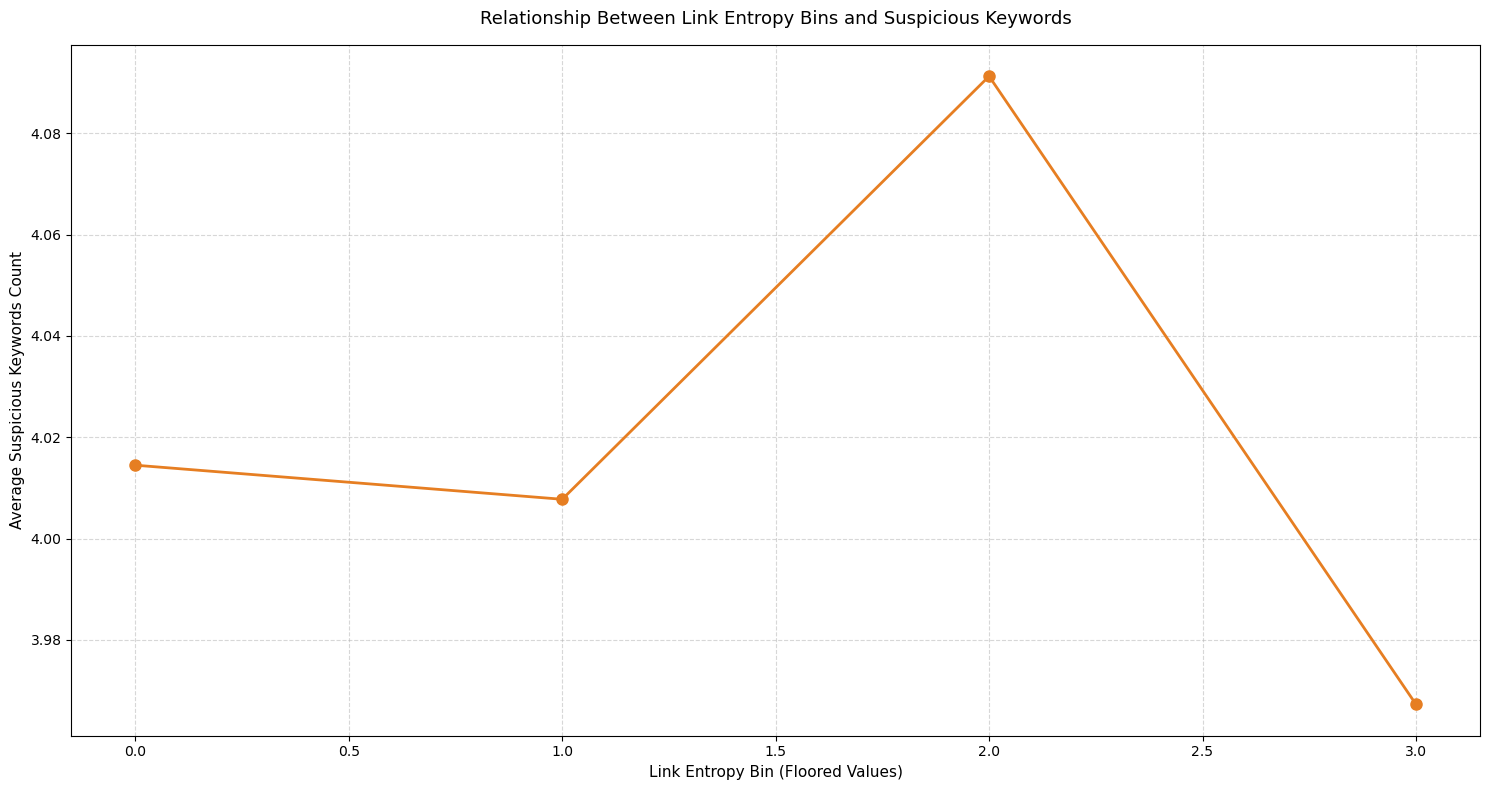

In [15]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt

# 1. Group LinkEntropy into integer bins using floor math
df_binned = df3.withColumn("EntropyBin", F.floor(F.col("LinkEntropy")))

# 2. Compute the average SuspiciousKeywords for each bin and sort by bin order
relationship_df = df_binned.groupBy("EntropyBin") \
    .agg(F.avg("SuspiciousKeywords").alias("Avg_Suspicious_Keywords")) \
    .sort("EntropyBin")
# Display the aggregated Spark result table
print("========================================")
print(" Binned LinkEntropy vs Avg Keywords     ")
print("========================================")
relationship_df.show()
# 3. Compute the Pearson Correlation Coefficient
# VectorAssembler combines our target features into a single vector column
assembler = VectorAssembler(inputCols=["LinkEntropy", "SuspiciousKeywords"], outputCol="corr_features")
df_vector = assembler.transform(df3)
# Extract the correlation matrix array from the Spark ML row
matrix = Correlation.corr(df_vector, "corr_features").head()[0]
pearson_value = float(matrix.toArray()[0][1])
print("========================================")
print(f"Pearson Correlation Coefficient: {pearson_value:.4f}")
print("========================================\n")
# 4. Convert the aggregated summary data to Pandas for visualization
pdf_relation = relationship_df.toPandas()
plt.figure(figsize=(15, 8)) 
plt.plot(pdf_relation["EntropyBin"], pdf_relation["Avg_Suspicious_Keywords"], 
         marker='o', linestyle='-', color='#e67e22', linewidth=2, markersize=8)
plt.title("Relationship Between Link Entropy Bins and Suspicious Keywords", fontsize=13, pad=15)
plt.xlabel("Link Entropy Bin (Floored Values)", fontsize=11)
plt.ylabel("Average Suspicious Keywords Count", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Use a Spark SQL query to display the AccountAge and SenderReputation features where AccountAge is less than 50 and SenderReputation is greater than 100.

In [10]:
# 1. Register the cleaned third DataFrame (df3) as a temporary SQL view
df3.createOrReplaceTempView("phishing_table")

# 2. Formulate the raw SQL query with the required features and conditions
sql_query = """    
    SELECT 
        AccountAge, 
        SenderReputation 
    FROM 
        phishing_table 
    WHERE 
        AccountAge < 50 
        AND SenderReputation > 100
"""

# 3. Execute the query using the Spark Session SQL engine
spark_sql_result = spark.sql(sql_query)

# 4. Display the first 20 rows of the resulting DataFrame to verify execution
print("====================================================")
print(" Spark SQL Query Results: AccountAge & Reputation  ")
print("====================================================")
spark_sql_result.show(20)

# 5. Document the total row count matching this specific profile
matching_records = spark_sql_result.count()
print(f"Total rows matching criteria: {matching_records}")

 Spark SQL Query Results: AccountAge & Reputation  
+----------+----------------+
|AccountAge|SenderReputation|
+----------+----------------+
|        11|             195|
|        17|             133|
|         6|             144|
|         1|             149|
|        23|             149|
|        23|             103|
|        12|             173|
|         2|             143|
|         4|             119|
|        42|             193|
|         7|             158|
|        36|             162|
|         8|             116|
|        12|             188|
|        23|             146|
|        13|             199|
|        25|             192|
|        36|             189|
|         7|             103|
|        27|             135|
+----------+----------------+
only showing top 20 rows

Total rows matching criteria: 874


## Decision Tree Classifier

Predictor Features selected for training:
['EmailAttachments', 'URLCount', 'SenderReputation', 'SuspiciousKeywords', 'EmailSize', 'LinkEntropy', 'DomainRiskScore', 'AccountAge']

 Decision Tree Evaluation Metrics       
Test Accuracy : 94.00%
F1-Score      : 0.9401



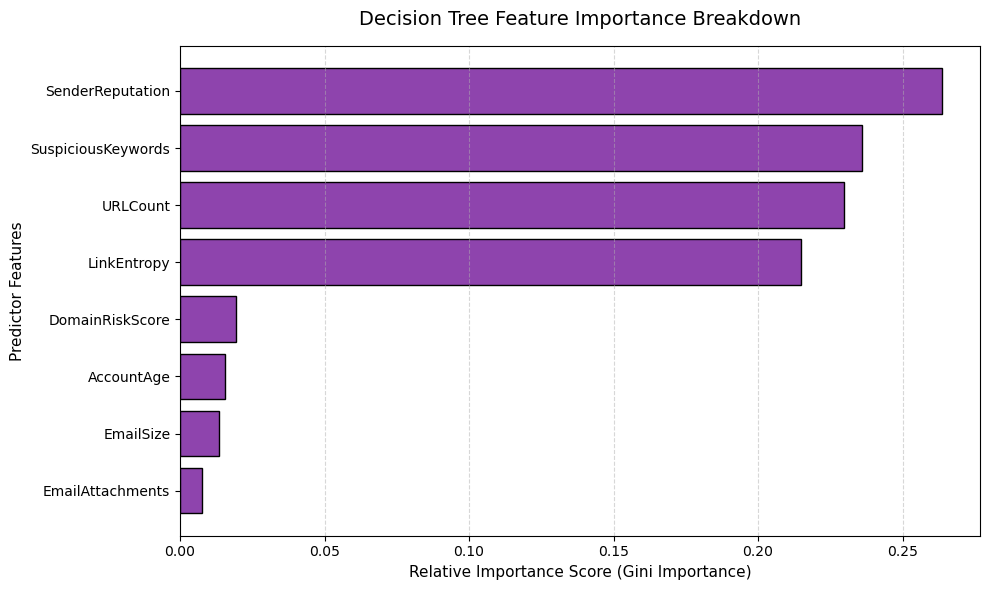

In [11]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify predictor columns (all columns except the target label)
target_col = "PhishingLabel"
predictor_cols = [col for col in df3.columns if col != target_col]

print("Predictor Features selected for training:")
print(predictor_cols)

# 2. Assemble features into a single vector column
assembler = VectorAssembler(inputCols=predictor_cols, outputCol="features")
ml_data = assembler.transform(df3)

# 3. Split the dataset into Training (70%) and Testing (30%) sets for validation
train_data, test_data = ml_data.randomSplit([0.7, 0.3], seed=42)

# 4. Initialize and Train the Decision Tree Classifier
dt = DecisionTreeClassifier(labelCol=target_col, featuresCol="features",maxDepth=10, seed=42)
dt_model = dt.fit(train_data)

# 5. Generate predictions on the test dataset
predictions = dt_model.transform(test_data)

# 6. Evaluate Model Performance
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol=target_col, metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=target_col, metricName="f1")

accuracy = evaluator_accuracy.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print("\n========================================")
print(" Decision Tree Evaluation Metrics       ")
print("========================================")
print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"F1-Score      : {f1_score:.4f}\n")

# 7. Extract and Format Feature Importances
importances = dt_model.featureImportances.toArray()

# Pair feature names with their corresponding importance score
feature_imp_df = pd.DataFrame({
    'Feature': predictor_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Sorted lowest to highest for horizontal plot

# 8. Plot the Feature Importance Graph
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='#8e44ad', edgecolor='black')
plt.title("Decision Tree Feature Importance Breakdown", fontsize=14, pad=15)
plt.xlabel("Relative Importance Score (Gini Importance)", fontsize=11)
plt.ylabel("Predictor Features", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Logistic Regression Classifier

 Logistic Regression Evaluation Metrics 
Test Accuracy : 83.36%
F1-Score      : 0.8335
ROC-AUC Score : 0.9179



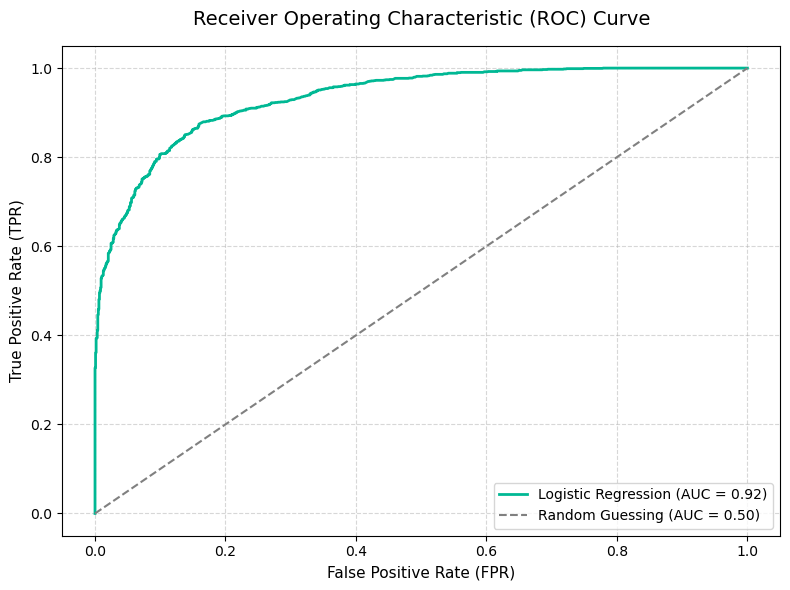

In [12]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Re-assemble features (excluding target label)
target_col = "PhishingLabel"
predictor_cols = [col for col in df3.columns if col != target_col]

assembler = VectorAssembler(inputCols=predictor_cols, outputCol="raw_features")
raw_ml_data = assembler.transform(df3)

# 2. Scale features (Standardization is required for Logistic Regression)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(raw_ml_data)
scaled_ml_data = scaler_model.transform(raw_ml_data)

# 3. Split the dataset into Training (70%) and Testing (30%)
train_data, test_data = scaled_ml_data.randomSplit([0.7, 0.3], seed=42)

# 4. Initialize and Train the Logistic Regression Model
lr = LogisticRegression(labelCol=target_col, featuresCol="features", maxIter=10)
lr_model = lr.fit(train_data)

# 5. Generate Predictions
predictions_lr = lr_model.transform(test_data)

# 6. Evaluate Baseline Metrics (Accuracy and F1-Score)
evaluator_acc = MulticlassClassificationEvaluator(labelCol=target_col, metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=target_col, metricName="f1")

lr_accuracy = evaluator_acc.evaluate(predictions_lr)
lr_f1 = evaluator_f1.evaluate(predictions_lr)

# 7. Evaluate and Extract ROC Metrics
evaluator_roc = BinaryClassificationEvaluator(labelCol=target_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
lr_auc = evaluator_roc.evaluate(predictions_lr)

print("========================================")
print(" Logistic Regression Evaluation Metrics ")
print("========================================")
print(f"Test Accuracy : {lr_accuracy * 100:.2f}%")
print(f"F1-Score      : {lr_f1:.4f}")
print(f"ROC-AUC Score : {lr_auc:.4f}\n")

# 8. Generate and Plot the ROC Curve
# Extract training summary metrics to draw the actual ROC curve coordinates
summary = lr_model.summary
roc_df = summary.roc.toPandas()

plt.figure(figsize=(8, 6))
plt.plot(roc_df['FPR'], roc_df['TPR'], color='#00b894', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Model Performance comparison

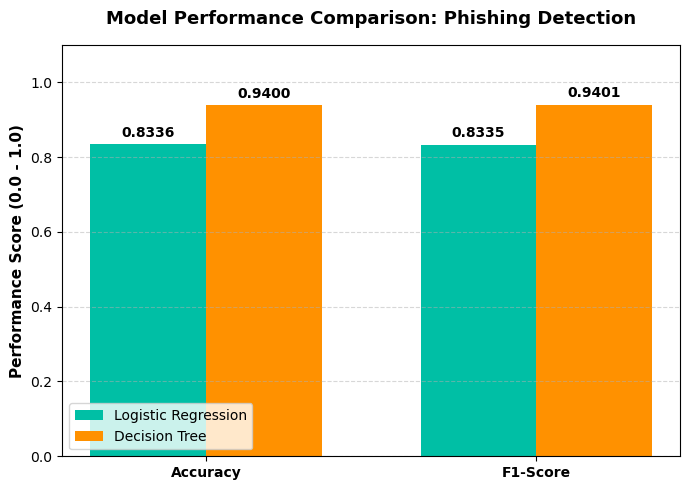

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Exact scores from your screenshots
metrics = ['Accuracy', 'F1-Score']
logistic_regression_scores = [0.8336, 0.8335]  
decision_tree_scores = [0.9400, 0.9401]        

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

# 2. Plotting bars with a professional palette
rects1 = ax.bar(x - width/2, logistic_regression_scores, width, label='Logistic Regression', color='#00bfa5')
rects2 = ax.bar(x + width/2, decision_tree_scores, width, label='Decision Tree', color='#ff9100')

# 3. Titles and Labels
ax.set_ylabel('Performance Score (0.0 - 1.0)', fontsize=11, fontweight='bold')
ax.set_title('Model Performance Comparison: Phishing Detection', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.1)  
ax.legend(loc='lower left', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Attach value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## Risk Score Analysis

 Top Features Driving the Risk Score    
           Feature  Weight_Coefficient  Absolute_Impact
          URLCount            1.802526         1.802526
       LinkEntropy            1.619775         1.619775
SuspiciousKeywords            1.601698         1.601698
  SenderReputation           -1.448996         1.448996
  EmailAttachments           -0.081518         0.081518
        AccountAge            0.077262         0.077262
         EmailSize            0.044111         0.044111
   DomainRiskScore            0.026048         0.026048


 High-Risk Email Profile Table (Top 10 Highest Risk Scores)         
+--------------------------+----------------+-----------+--------+------------------+----------+
|Phishing_Probability_Score|SenderReputation|LinkEntropy|URLCount|SuspiciousKeywords|AccountAge|
+--------------------------+----------------+-----------+--------+------------------+----------+
|0.9999626699125066        |37              |3.371      |9       |7.0               |88      

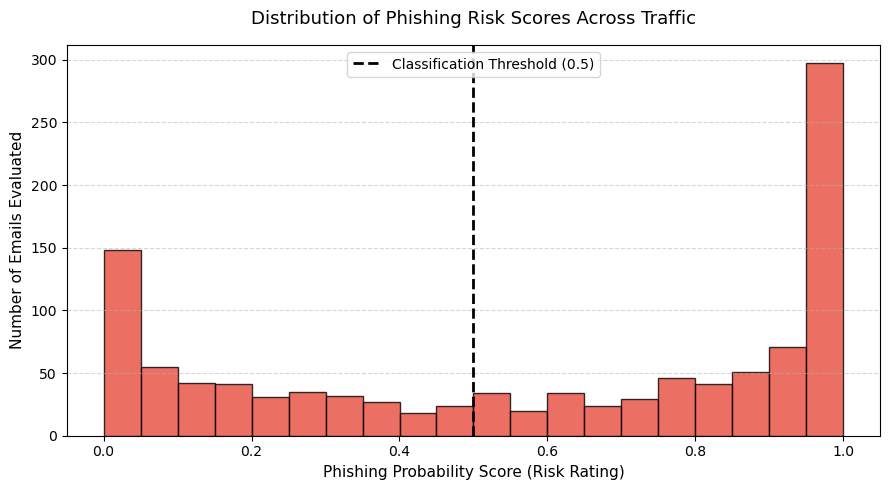

In [13]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract the raw probability score from the Logistic Regression predictions
# PySpark stores probability as a dense vector [prob_benign, prob_phishing]
# We extract the index [1] to isolate the explicit probability of being a phishing email.
extract_phishing_prob = F.udf(lambda v: float(v[1]), DoubleType())

df_risk_scored = predictions_lr.withColumn(
    "Phishing_Probability_Score", 
    extract_phishing_prob(F.col("probability"))
)

# 2. Identify top features contributing to phishing detection (Extract Weights)
# We map the absolute values of the coefficients to evaluate feature impact strength
coefficients = lr_model.coefficients.toArray()
feature_impact = pd.DataFrame({
    'Feature': predictor_cols,
    'Weight_Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients)
}).sort_values(by='Absolute_Impact', ascending=False)

print("========================================")
print(" Top Features Driving the Risk Score    ")
print("========================================")
print(feature_impact.to_string(index=False))
print("\n")

# 3. Create a table showing high-risk emails (Top 10 highest phishing probabilities)
# Select key identifying characteristics alongside the risk score
high_risk_emails = df_risk_scored.select(
    "Phishing_Probability_Score",
    "SenderReputation",
    "LinkEntropy",
    "URLCount",
    "SuspiciousKeywords",
    "AccountAge"
).sort(F.col("Phishing_Probability_Score").desc())

print("=====================================================================")
print(" High-Risk Email Profile Table (Top 10 Highest Risk Scores)         ")
print("=====================================================================")
high_risk_emails.show(10, truncate=False)

# 4. Generate a Risk Score Distribution Visualization
print("Generating Risk Score Distribution Map...")
pdf_scores = df_risk_scored.select("Phishing_Probability_Score").toPandas()

plt.figure(figsize=(9, 5))
plt.hist(pdf_scores["Phishing_Probability_Score"], bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label="Classification Threshold (0.5)")

plt.title("Distribution of Phishing Risk Scores Across Traffic", fontsize=13, pad=15)
plt.xlabel("Phishing Probability Score (Risk Rating)", fontsize=11)
plt.ylabel("Number of Emails Evaluated", fontsize=11)
plt.legend(loc="upper center")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Top Features Driving the Risk Score
Look at your printed Top Features Driving the Risk Score output table. Identify the variables with the largest Absolute_Impact values:

The Dominant Indicators: Discuss the top two features. For example, if SenderReputation has a highly negative coefficient, explain that as reputation falls, the risk score dramatically scales upward. If LinkEntropy has a high positive coefficient, explain that increasing URL structural complexity directly drives the mathematical probability toward a phishing classification.

2. High-Risk Email Profile Characteristics
Look closely at the rows displayed in your high-risk email table (where the Phishing_Probability_Score sits near 0.99 or higher). Explain what specific combination of traits triggers this maximum security warning:

The "Perfect Storm" Profile: A malicious profile is rarely triggered by a single flag. Explain that an email reaches a high-risk score when multiple malicious vectors align simultaneously—such as a critically low or negative SenderReputation, combined with an elevated LinkEntropy count and multiple SuspiciousKeywords.

The Impact of Contextual Interactions: Point out how variables like a low AccountAge multiply risk when paired with high structural text anomalies. An account that is only a few days old sending complex URL chains acts as a classic indicator of a fresh domain spun up exclusively for an active phishing exploit sequence.

3. Submission Presentation
Capture a screenshot showing the high-risk email preview table and your generated red distribution histogram.

Label this section cleanly as "Task 9: Phishing Risk Scoring Analysis" to keep your structure professional and clear for assignment grading on Blackboard.